In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [2]:
file_path = "KMeans_Hierarchical_Clustering_Data.xlsx"

data = pd.read_excel(
    file_path,
    sheet_name="Sheet1"
)

data.head()

,Feature1,Feature2,Feature3,Feature4,Feature5
0,4.5,2.3,1.3,0.3,1.0
1,5.1,3.5,1.4,0.2,1.1
2,6.0,2.7,5.1,1.6,2.5
3,5.9,3.0,5.1,1.8,2.3
4,4.9,2.5,4.5,1.7,2.1


In [3]:
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print("\nMissing Values:")
print(data.isnull().sum())

Shape: (72, 5)
Columns: ['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5']

Missing Values:
Feature1    0
Feature2    0
Feature3    0
Feature4    0
Feature5    0
dtype: int64


In [4]:
X = data[
    ["Feature1", "Feature2", "Feature3", "Feature4", "Feature5"]
]

In [5]:
X.describe()

,Feature1,Feature2,Feature3,Feature4,Feature5
count,72.000000,72.000000,72.000000,72.000000,72.000000
mean,5.673611,3.070833,3.476389,1.087500,1.887500
std,0.625512,0.439410,1.579133,0.684216,0.647626
min,4.500000,2.200000,1.000000,0.100000,1.000000
25%,5.175000,2.775000,1.600000,0.300000,1.100000
50%,5.650000,3.000000,4.000000,1.300000,2.100000
75%,6.025000,3.400000,4.725000,1.600000,2.400000
max,7.200000,4.100000,6.100000,2.500000,3.000000


In [6]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    
    inertia.append(kmeans.inertia_)

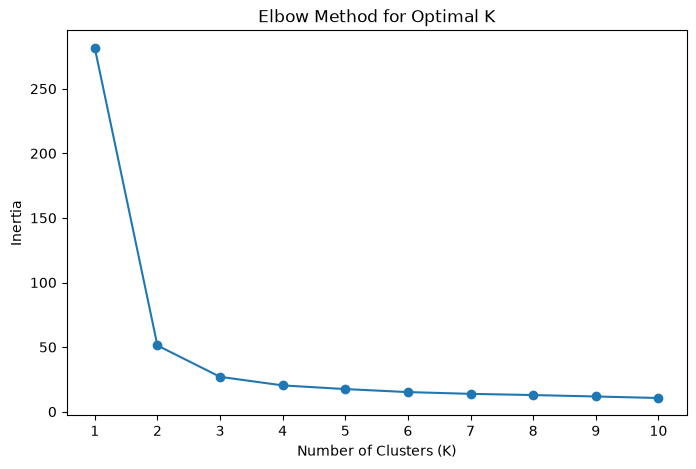

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(range(1, 11))
plt.show()

In [8]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(
        X,
        labels
    )
    
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "Number of Clusters": range(2, 11),
    "Silhouette Score": silhouette_scores
})

silhouette_results

,Number of Clusters,Silhouette Score
0,2,0.722122
1,3,0.564547
2,4,0.530626
3,5,0.392650
4,6,0.360493
5,7,0.362158
6,8,0.261051
7,9,0.296979
8,10,0.277673


In [9]:
optimal_k = 3

In [10]:
kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X)

In [11]:
kmeans_data = data.copy()

kmeans_data["KMeans_Cluster"] = kmeans_labels

kmeans_data.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,KMeans_Cluster
0,4.5,2.3,1.3,0.3,1.0,1
1,5.1,3.5,1.4,0.2,1.1,1
2,6.0,2.7,5.1,1.6,2.5,0
3,5.9,3.0,5.1,1.8,2.3,0
4,4.9,2.5,4.5,1.7,2.1,2


In [12]:
print(
    kmeans_data["KMeans_Cluster"].value_counts().sort_index()
)

KMeans_Cluster
0    21
1    26
2    25
Name: count, dtype: int64


In [13]:
linked = linkage(
    X,
    method="ward"
)

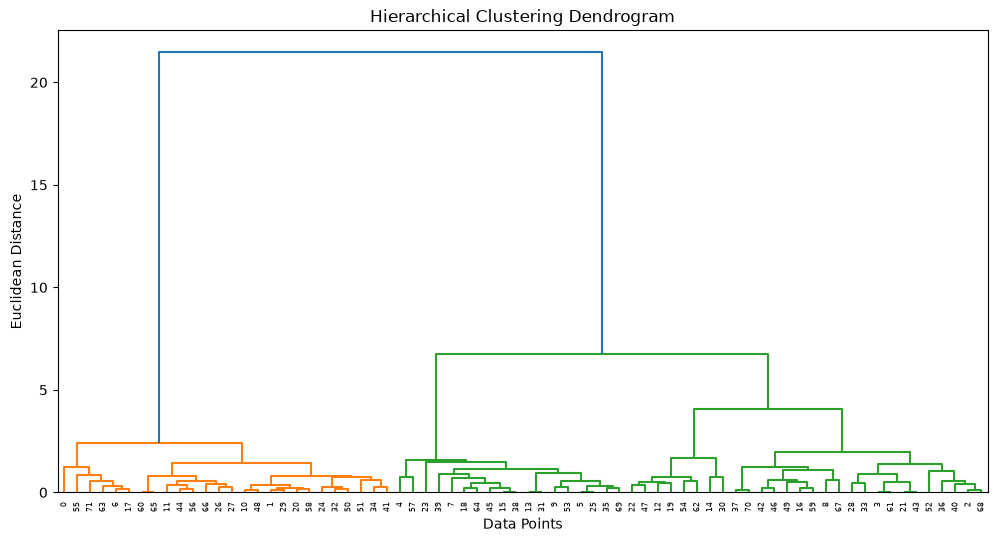

In [14]:
plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

plt.show()

In [15]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X)

In [16]:
hierarchical_data = data.copy()

hierarchical_data[
    "Hierarchical_Cluster"
] = hierarchical_labels

hierarchical_data.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Hierarchical_Cluster
0,4.5,2.3,1.3,0.3,1.0,1
1,5.1,3.5,1.4,0.2,1.1,1
2,6.0,2.7,5.1,1.6,2.5,0
3,5.9,3.0,5.1,1.8,2.3,0
4,4.9,2.5,4.5,1.7,2.1,2


In [17]:
print(
    hierarchical_data[
        "Hierarchical_Cluster"
    ].value_counts().sort_index()
)

Hierarchical_Cluster
0    28
1    26
2    18
Name: count, dtype: int64


In [18]:
cluster_comparison = data.copy()

cluster_comparison["KMeans_Cluster"] = kmeans_labels

cluster_comparison[
    "Hierarchical_Cluster"
] = hierarchical_labels

cluster_comparison.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,KMeans_Cluster,Hierarchical_Cluster
0,4.5,2.3,1.3,0.3,1.0,1,1
1,5.1,3.5,1.4,0.2,1.1,1,1
2,6.0,2.7,5.1,1.6,2.5,0,0
3,5.9,3.0,5.1,1.8,2.3,0,0
4,4.9,2.5,4.5,1.7,2.1,2,2


In [19]:
print("K-Means Cluster Sizes:")
print(
    pd.Series(kmeans_labels)
    .value_counts()
    .sort_index()
)

print("\nHierarchical Cluster Sizes:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

K-Means Cluster Sizes:
0    21
1    26
2    25
Name: count, dtype: int64

Hierarchical Cluster Sizes:
0    28
1    26
2    18
Name: count, dtype: int64


In [22]:
cluster_cross_tab = pd.crosstab(
    cluster_comparison["KMeans_Cluster"],
    cluster_comparison["Hierarchical_Cluster"]
)

cluster_cross_tab

Hierarchical_Cluster,0,1,2
KMeans_Cluster,,,
0,21,0,0
1,0,26,0
2,7,0,18


In [21]:
kmeans_silhouette = silhouette_score(
    X,
    kmeans_labels
)

hierarchical_silhouette = silhouette_score(
    X,
    hierarchical_labels
)

print(
    "K-Means Silhouette Score:",
    kmeans_silhouette
)

print(
    "Hierarchical Silhouette Score:",
    hierarchical_silhouette
)

K-Means Silhouette Score: 0.5645472812077171
Hierarchical Silhouette Score: 0.5449387378370868


K-Means and Hierarchical clustering were applied to the same dataset using the same number of clusters. The resulting cluster assignments were compared using cluster sizes, a cross-tabulation, and silhouette scores. Differences between the two methods can occur because K-Means iteratively assigns observations to centroids, whereas hierarchical clustering builds a hierarchy of observations based on distances and linkage.

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
scaled_inertia = []

for k in range(1, 11):
    kmeans_scaled = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans_scaled.fit(X_scaled)
    
    scaled_inertia.append(
        kmeans_scaled.inertia_
    )

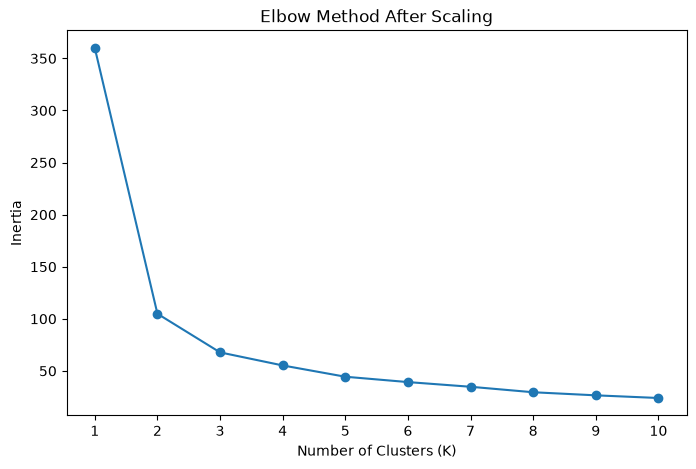

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    scaled_inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method After Scaling")

plt.xticks(range(1, 11))
plt.show()

In [26]:
kmeans_scaled_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

scaled_labels = kmeans_scaled_final.fit_predict(
    X_scaled
)

In [27]:
scaled_silhouette = silhouette_score(
    X_scaled,
    scaled_labels
)

print(
    "Silhouette Score Before Scaling:",
    kmeans_silhouette
)

print(
    "Silhouette Score After Scaling:",
    scaled_silhouette
)

Silhouette Score Before Scaling: 0.5645472812077171
Silhouette Score After Scaling: 0.4807140136745684


In [28]:
scaling_comparison = pd.DataFrame({
    "Original Cluster": kmeans_labels,
    "Scaled Cluster": scaled_labels
})

scaling_comparison.head(20)

,Original Cluster,Scaled Cluster
0,1,1
1,1,1
2,0,2
3,0,0
4,2,2
5,2,2
6,1,1
7,2,2
8,0,2
9,2,2


Scaling changes the relative contribution of the features to distance calculations. Since K-Means uses distances to determine cluster assignments, features with larger numerical ranges can otherwise have a greater influence on the clustering. Standardization puts the features on a comparable scale and can therefore change both cluster assignments and clustering performance.

In [29]:
def evaluate_clustering(X_data, labels):
    score = silhouette_score(
        X_data,
        labels
    )
    
    return score

In [30]:
kmeans_score = evaluate_clustering(
    X,
    kmeans_labels
)

print(
    "K-Means Silhouette Score:",
    kmeans_score
)

K-Means Silhouette Score: 0.5645472812077171


In [31]:
hierarchical_score = evaluate_clustering(
    X,
    hierarchical_labels
)

print(
    "Hierarchical Silhouette Score:",
    hierarchical_score
)

Hierarchical Silhouette Score: 0.5449387378370868


In [32]:
scaled_score = evaluate_clustering(
    X_scaled,
    scaled_labels
)

print(
    "Scaled K-Means Silhouette Score:",
    scaled_score
)

Scaled K-Means Silhouette Score: 0.4807140136745684


In [33]:
final_clustering_comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "Hierarchical",
        "Scaled K-Means"
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score,
        scaled_score
    ]
})

final_clustering_comparison

,Method,Silhouette Score
0,K-Means,0.564547
1,Hierarchical,0.544939
2,Scaled K-Means,0.480714
